In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine

# 1. Bulut Veritabanı Bağlantısı (SQLAlchemy)
import os
from dotenv import load_dotenv

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

# 2. Veriyi Çekme
query = "SELECT * FROM sentiment_data;"
df_raw = pd.read_sql_query(query, con=engine)

# 3. Mükerrer Verileri Temizleme
df = df_raw.drop_duplicates(subset=['text']).copy()

print(f"✅ Ham Veri Satır Sayısı: {len(df_raw)}")
print(f"✨ Temizlenmiş (Tekil) Veri Satır Sayısı: {len(df)}")

df.head()

✅ Ham Veri Satır Sayısı: 32
✨ Temizlenmiş (Tekil) Veri Satır Sayısı: 27


,id,timestamp,source,text,compound_score,sentiment_label
0,1,2026-09-08 18:02:37.440143+00:00,Reddit,Bitcoin is going to the moon! Best investment ...,0.6988,Positive
3,4,2026-09-08 18:04:31.307659+00:00,Reddit,Crypto market trading volume remained flat today.,0.0000,Neutral
6,7,2026-09-08 18:07:11.168837+00:00,Reddit,"Ethereum market crash is terrible, I lost all ...",-0.7964,Negative
8,9,2026-09-08 18:52:47.177792+00:00,Reddit_Crypto,(More) Thoughts on $Hookr?,0.0000,Neutral
9,10,2026-09-08 18:52:48.228315+00:00,Reddit_Crypto,For people in high-inflation countries: do you...,0.0000,Neutral


In [12]:
# Sayısal sütunların istatistiksel özeti
df.describe()

,id,compound_score
count,27.000000,27.000000
mean,18.666667,-0.026815
std,8.534996,0.369114
min,1.000000,-0.796400
25%,12.500000,-0.212900
50%,19.000000,0.000000
75%,25.500000,0.101150
max,32.000000,0.698800


Ortalama (mean): -0.0268 (Genel duygu durumu sıfıra, yani nötre çok yakın ama hafif negatif)

Medyan (50%): 0.0000 (Verilerin tam ortasındaki değer tam olarak nötr)

Minimum (min): -0.7964 (En olumsuz/kötümser duygu skoru 📉)

Maksimum (max): 0.6988 (En olumlu/iyimser duygu skoru 📈)

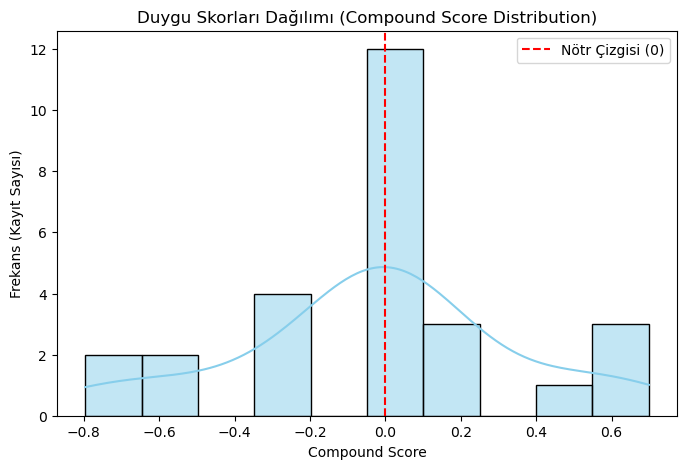

In [13]:
# Duygu skorlarının (compound_score) dağılımını görselleştirme
plt.figure(figsize=(8, 5))
sns.histplot(df['compound_score'], kde=True, bins=10, color='skyblue')

plt.title('Duygu Skorları Dağılımı (Compound Score Distribution)')
plt.xlabel('Compound Score')
plt.ylabel('Frekans (Kayıt Sayısı)')
plt.axvline(0, color='red', linestyle='--', label='Nötr Çizgisi (0)')
plt.legend()
plt.show()

In [14]:
# Sentiment etiketlerinin dağılımı (Positive, Neutral, Negative)
df['sentiment_label'].value_counts()

sentiment_label
Neutral     12
Negative     8
Positive     7
Name: count, dtype: int64

In [15]:
# Duygu etiketlerine göre ortalama compound_score değerleri
df.groupby('sentiment_label')['compound_score'].mean()

sentiment_label
Negative   -0.456437
Neutral     0.000000
Positive    0.418214
Name: compound_score, dtype: float64

In [16]:
# Verinin hangi kaynaklardan geldiğini görelim
df['source'].value_counts()

source
Reddit_Crypto         8
News/CryptoSlate      6
News/CoinDesk         5
News/CoinTelegraph    5
Reddit                3
Name: count, dtype: int64

In [17]:
# Metin içinde geçen kripto paraları tespit eden fonksiyon
def detect_coin(text):
    text_lower = str(text).lower()
    if 'bitcoin' in text_lower or 'btc' in text_lower:
        return 'Bitcoin'
    elif 'ethereum' in text_lower or 'eth' in text_lower:
        return 'Ethereum'
    else:
        return 'Diğer / Genel Crypto'

# Yeni sütunu oluşturma
df['coin'] = df['text'].apply(detect_coin)

# Kripto varlıkların frekansı
df['coin'].value_counts()

coin
Diğer / Genel Crypto    18
Bitcoin                  5
Ethereum                 4
Name: count, dtype: int64

In [18]:
# Kripto varlıklara göre ortalama duygu skorları
df.groupby('coin')['compound_score'].mean()

coin
Bitcoin                -0.115280
Diğer / Genel Crypto    0.013567
Ethereum               -0.097950
Name: compound_score, dtype: float64

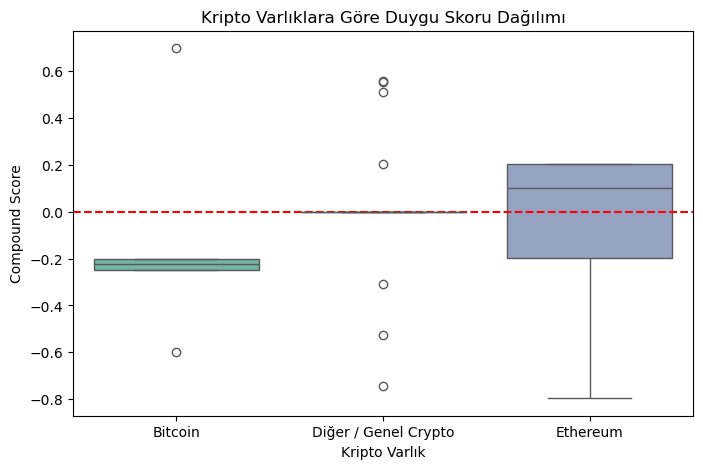

In [19]:
# Kripto varlıklara göre duygu skorlarının Box Plot ile görselleştirilmesi
plt.figure(figsize=(8, 5))

sns.boxplot(x='coin', y='compound_score', data=df, hue='coin', palette='Set2', legend=False)

plt.title('Kripto Varlıklara Göre Duygu Skoru Dağılımı')
plt.xlabel('Kripto Varlık')
plt.ylabel('Compound Score')
plt.axhline(0, color='red', linestyle='--', label='Nötr Çizgisi')

plt.show()

In [20]:
# ANOVA Testi Uygulama
btc_scores = df[df['coin'] == 'Bitcoin']['compound_score']
eth_scores = df[df['coin'] == 'Ethereum']['compound_score']
other_scores = df[df['coin'] == 'Diğer / Genel Crypto']['compound_score']

f_stat, p_value = stats.f_oneway(btc_scores, eth_scores, other_scores)

print(f"🧪 F-İstatistiği: {f_stat:.4f}")
print(f"📊 p-değeri (p-value): {p_value:.4f}")

🧪 F-İstatistiği: 0.3083
📊 p-değeri (p-value): 0.7376


In [21]:
print(len(df_raw))

32
